# GSB 5544 — PA 2.2: Wrangling and Summarizing Data — SOLUTION

Read this notebook from top to bottom and fill in the code as you go. Work together and discuss with other students in the class. Try to resolve any errors on your own first, but don't get stuck; ask for help!

In addition to writing and running code, be sure to examine any output and interpret the results before moving on.

For many of these questions, there are several ways to do it in Pandas. You only need to choose one that works. But you might want to experiment with multiple ways of doing the same thing to get practice working with Pandas. However, you should generally try to find the simplest solution. In particular, use `groupby` whenever possible to streamline the code.

This completed version follows the Topic 2.2 workflow and includes rendered outputs.

In [1]:
import pandas as pd

## Titanic data

In [2]:
df_titanic = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/main/data/titanic.csv")
df_titanic

,name,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew
0,"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0,3.0,NaN
1,"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN
2,"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN
3,"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1,3.0,NaN
4,"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,1,3.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2202,"Wynn, Mr. Walter",male,41.0,deck crew,B,England,NaN,NaN,1,NaN,deck crew
2203,"Yearsley, Mr. Harry",male,40.0,victualling crew,S,England,NaN,NaN,1,NaN,victualling crew
2204,"Young, Mr. Francis James",male,32.0,engineering crew,S,England,NaN,NaN,0,NaN,engineering crew
2205,"Zanetti, Sig. Minio",male,20.0,restaurant staff,S,England,NaN,NaN,0,NaN,restaurant staff


1\. Create a new variable "type" that takes values either "passenger" or "crew".

In [3]:
import numpy as np
df_titanic["type"] = np.where(df_titanic["crew"].notna(), "crew", "passenger")
df_titanic[["class", "type"]].value_counts()

class             type     
3rd               passenger    709
victualling crew  crew         431
1st               passenger    324
engineering crew  crew         324
2nd               passenger    284
restaurant staff  crew          69
deck crew         crew          66
Name: count, dtype: int64

2\. Find the proportion those onboard who were passengers and the proportion who were crew. Do this by creating a Series with these proportions.

In [4]:
df_titanic["type"].value_counts(normalize=True)

type
passenger    0.596738
crew         0.403262
Name: proportion, dtype: float64

3\. Note that "survived" is a categorical variable that has been one-hot encoded as a dummy (aka Bernoulli aka indicator) numerical variable with 1 = survived and 0 = not survived. (Check its dtype.) Find the proportion of those onboard who survived. You could do this with `value_counts` like for "type", but try a different way that takes advantage of the fact that "survived" is a numerical type. (Hint: what happens if you sum the values of a 1/0 variable? What happens if you take the mean of the values of a 1/0 variable?)

In [5]:
df_titanic["survived"].mean()

np.float64(0.3221567739012234)

4\. Create a crosstab (two-way table) summarizing the joint distribution of "survived" and "type". (Notice that we can treat the dummy variable "survived" as both a categorical variable and a numerical variable, whichever is convenient.)

In [6]:
pd.crosstab(df_titanic["survived"], df_titanic["type"], margins=True)

type,crew,passenger,All
survived,,,
0,679,817,1496
1,211,500,711
All,890,1317,2207


5\. Compare the proportion of passengers who survived and the proportion of crew members who survived. Do this by creating a Series that contains these two proportions. Who was more likely to survive: passengers or crew?

Hint: there are a few ways of doing this, several of which avoid explicitly dividing. Can you take advantage of `groupby` and the fact that "survived" is a dummy variable?

In [7]:
df_titanic.groupby("type")["survived"].mean()

type
crew         0.237079
passenger    0.379651
Name: survived, dtype: float64

6\. The "gender" variable is coded only as "male" or "female". Among males only, compare the proportion of passengers who survived and the proportion of cew who survived. Among males, who was more likely to survive: passengers or crew? Then do the same thing among females only. Among females, who was more likely to survive: passengers or crew?

Do this by creating a Series that contains the 4 proportions you need. Hint: if you used `groupby` in the previous part you should only need a small change here.

In [8]:
df_titanic.groupby(["gender", "type"])["survived"].mean()

gender  type     
female  crew         0.869565
        passenger    0.727468
male    crew         0.220300
        passenger    0.189189
Name: survived, dtype: float64

7\. Compare your answers to 5 and 6. What do you notice? Can you explain why this happens? Suggest an explanation and then create summaries of the data to support your explanation.

In [9]:
# Passenger/crew survival reverses after accounting for gender (Simpson's paradox).
pd.crosstab(df_titanic["gender"], df_titanic["type"], normalize="columns").round(3)

type,crew,passenger
gender,,
female,0.026,0.354
male,0.974,0.646


## College Scorecard

The [College Scorecard](https://collegescorecard.ed.gov/) was an effort started by the U.S. Department of Education to help students make more informed choices about colleges. Data from 2022 is available at https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/college_scorecard_2022.csv


In [10]:
df_college = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/college_scorecard_2022.csv")

df_college

,Institution,City,State,Undergraduates,Median Earnings
0,Alabama A & M University,Normal,AL,5098.0,39059.0
1,University of Alabama at Birmingham,Birmingham,AL,13284.0,50907.0
2,Amridge University,Montgomery,AL,251.0,37730.0
3,University of Alabama in Huntsville,Huntsville,AL,7358.0,56901.0
4,Alabama State University,Montgomery,AL,3495.0,34018.0
...,...,...,...,...,...
6538,Pennsylvania State University-Penn State York,York,PA,NaN,61185.0
6539,Pennsylvania State University-Penn State Great...,Malvern,PA,NaN,61185.0
6540,Pennsylvania State University-Penn State Harri...,Middletown,PA,NaN,61185.0
6541,Pennsylvania State University-Penn State Brand...,Media,PA,NaN,61185.0


1\. What is the observational unit? Make a guess for how the earnings variable is computed.

**Solution:** The observational unit is one college. `earnings` is the median annual earnings, ten years after entry, among federally aided former students whose tax records are available.

2\. Write code to find the California Polytechnic row in the data set!

In [11]:
df_college[df_college["Institution"].str.contains("California Polytechnic", case=False, na=False)]

,Institution,City,State,Undergraduates,Median Earnings
194,California Polytechnic State University-San Lu...,San Luis Obispo,CA,21090.0,85801.0


3\. The data set contains information about the median earnings of students who attended each college, 10 years after they first enrolled. The earnings are taken directly from the W2 tax forms of all students who received federal financial aid.

Notice the earnings are missing (NaN). Create a subset data frame that only includes colleges with non-missing earnings. Use this subset to answer the remaining questions.

In [12]:
df_college_complete = df_college.dropna(subset=["Median Earnings"]).copy()
df_college_complete.shape

(5165, 5)

4\. Summarize the earnings variable, by finding the sample size, mean, SD, and *five number summary* (minimum, 25th percentile, median, 75th percentile, maximum). Hint: you can do all this with a single command! What is larger: the mean or the median? Why? Then create a histogram of the earnings variable.

<Axes: >

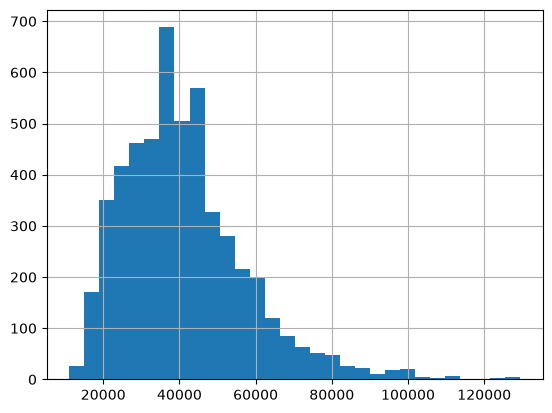

In [13]:
df_college_complete["Median Earnings"].describe()
df_college_complete["Median Earnings"].hist(bins=30)

5\. Create a new column with the log of earnings, then create a histogram. How does the shape of the histogram of log earnings compare to earnings itself?

<Axes: >

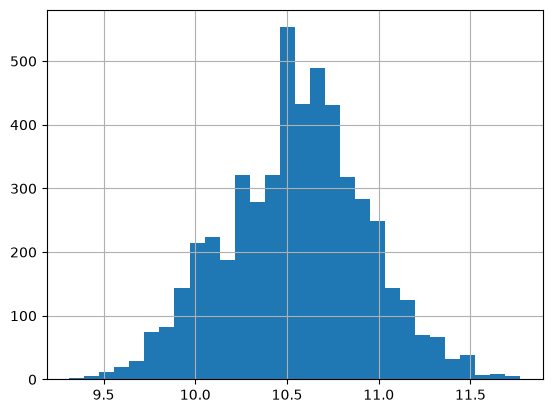

In [14]:
df_college_complete["log_earnings"] = np.log(df_college_complete["Median Earnings"])
df_college_complete["log_earnings"].hist(bins=30)

6\. The mean gives every college equal weight. But some colleges are tiny (e.g., San Francisco Conservatory, with 228 undergraduates), while others are large (e.g., Penn State, with 72229 undergraduates!).

If we are interested in what *students* earn, we might want to give more weight to colleges with more students. To do this, we can calculate a **weighted mean**:

$$ \sum_{i=1}^n w_i x_i. $$

In general, the weights $w_1, w_2, ..., w_n$ should all be non-negative and should add up to $1.0$. (For the usual mean, every observation gets equal weight, $1/n$.)

Calculate a weighted mean of earnings, using the undergraduate enrollments as weights. Do this by first adding a "weight" column to the data set (number of undegraduates for the college divided by the total number of undergraduates in the data set).

In [15]:
df_college_complete["weight"] = df_college_complete["Undergraduates"] / df_college_complete["Undergraduates"].sum()
(df_college_complete["weight"] * df_college_complete["Median Earnings"]).sum()

np.float64(50608.33831282287)

7\. Compute the mean of earnings for each state. Sort the states in descending order of mean earnings. Display the results in a bar chart.

<Axes: xlabel='State'>

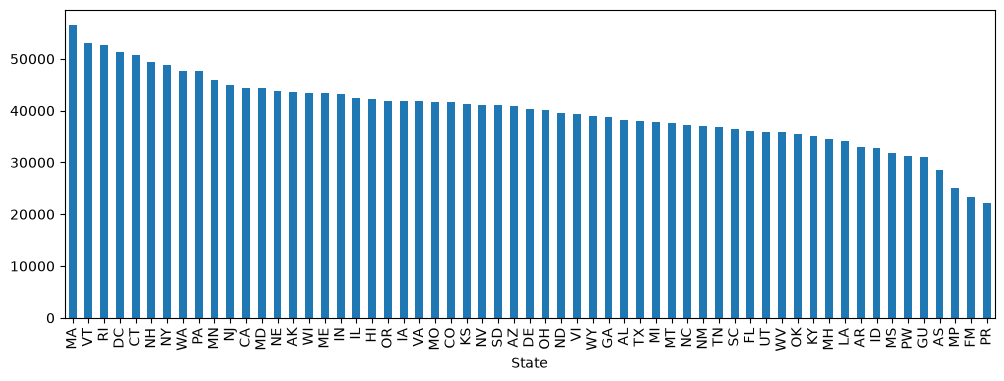

In [16]:
state_mean = df_college_complete.groupby("State")["Median Earnings"].mean().sort_values(ascending=False)
state_mean.plot.bar(figsize=(12, 4))

8\. Repeat the previous part, but now compute a weighted mean of earnings for each state, using the number of undegraduate enrollments in the state as weights. (Hint: use `groupby` with `transform`.)

<Axes: xlabel='State'>

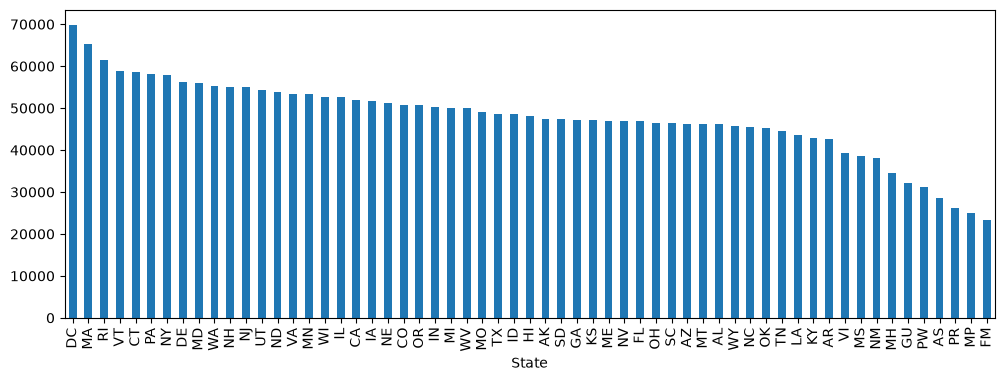

In [17]:
df_college_complete["state_total"] = df_college_complete.groupby("State")["Undergraduates"].transform("sum")
df_college_complete["state_weight"] = df_college_complete["Undergraduates"] / df_college_complete["state_total"]
df_college_complete["weighted_earnings"] = df_college_complete["Median Earnings"] * df_college_complete["state_weight"]
state_weighted_mean = df_college_complete.groupby("State")["weighted_earnings"].sum().sort_values(ascending=False)
state_weighted_mean.plot.bar(figsize=(12, 4))

## Olympic Men's Gymnastics Data



The file https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv contains scores from the qualification and final rounds of the Olympic men's gymnastics all around competition from 2008 to 2020. (Thanks to Martin Hsu for scraping this data set.)

In [18]:
df_gym = pd.read_csv("https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv")

df_gym

,Pos,Gymnast,NOC,Points,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse,Round,Year
0,1.0,Danell Leyva,USA,91.265,15.100,15.500,15.333,15.866,14.600,14.866,Qualification,2012
1,2.0,David Belyavsky,RUS,90.832,15.100,16.300,15.300,14.866,14.366,14.900,Qualification,2012
2,3.0,Fabian HambÃ¼chen,GER,90.765,15.133,15.833,15.300,15.633,14.766,14.100,Qualification,2012
3,4.0,John Orozco,USA,90.597,15.166,15.800,14.533,15.266,15.066,14.766,Qualification,2012
4,5.0,Kristian Thomas,GBR,90.256,15.366,16.200,14.625,15.366,14.566,14.133,Qualification,2012
...,...,...,...,...,...,...,...,...,...,...,...,...
346,20.0,Daniel Keatings,GBR,89.000,14.850,15.800,14.425,14.225,14.000,15.700,Final,2008
347,21.0,Thomas Bouhail,FRA,87.000,15.200,15.850,14.425,14.475,13.650,13.400,Final,2008
348,22.0,José Luis Fuentes,VEN,86.300,14.175,15.250,15.175,14.150,13.900,13.650,Final,2008
349,23.0,Dzmitry Savitski,BLR,82.175,13.725,15.900,13.400,10.100,15.300,13.750,Final,2008


1\. Create a data frame

- With [Round, Year, Gymnast] as the (multi) index, and
- Containing only the six columns with the event scores, "Floor Exercise" through "Pommelled Horse"

In [19]:
event_cols = df_gym.loc[:, "Floor Exercise":"Pommelled Horse"].columns.tolist()
gym_scores = df_gym.set_index(["Round", "Year", "Gymnast"])[event_cols].copy()
gym_scores

Floor Exercise  Horse Vault  \
Round         Year Gymnast                                          
Qualification 2012 Danell Leyva               15.100       15.500   
                   David Belyavsky            15.100       16.300   
                   Fabian HambÃ¼chen          15.133       15.833   
                   John Orozco                15.166       15.800   
                   Kristian Thomas            15.366       16.200   
...                                              ...          ...   
Final         2008 Daniel Keatings            14.850       15.800   
                   Thomas Bouhail             15.200       15.850   
                   José Luis Fuentes          14.175       15.250   
                   Dzmitry Savitski           13.725       15.900   
                   Chen Yibing                   NaN       15.900   

                                      Parallel Bars  Horizontal Bar   Rings  \
Round         Year Gymnast                                                    
Qualification 2012 Danell Leyva              15.333          15.866  14.600   
                   David Belyavsky           15.300          14.866  14.366   
                   Fabian HambÃ¼chen         15.300          15.633  14.766   
                   John Orozco               14.533          15.266  15.066   
                   Kristian Thomas           14.625          15.366  14.566   
...                                             ...             ...     ...   
Final         2008 Daniel Keatings           14.425          14.225  14.000   
                   Thomas Bouhail            14.425          14.475  13.650   
                   José Luis Fuentes         15.175          14.150  13.900   
                   Dzmitry Savitski          13.400          10.100  15.300   
                   Chen Yibing               14.950          12.975  16.650   

                                      Pommelled Horse  
Round         Year Gymnast                             
Qualification 2012 Danell Leyva                14.866  
                   David Belyavsky             14.900  
                   Fabian HambÃ¼chen           14.100  
                   John Orozco                 14.766  
                   Kristian Thomas             14.133  
...                                               ...  
Final         2008 Daniel Keatings             15.700  
                   Thomas Bouhail              13.400  
                   José Luis Fuentes           13.650  
                   Dzmitry Savitski            13.750  
                   Chen Yibing                 13.750  

[351 rows x 6 columns]

2\. Summarize the scores for each of the six events, by finding the sample size, mean, SD, and *five number summary* (minimum, 25th percentile, median, 75th percentile, maximum). Hint: you can do all this with a single command!

In [20]:
gym_scores.describe()

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
count,324.000000,323.000000,323.000000,324.000000,318.000000,325.000000
mean,14.309133,14.976551,14.719288,14.082562,14.237799,13.816723
std,1.254009,0.959876,0.920044,1.299542,0.914523,1.242348
min,1.633000,11.766000,10.200000,0.000000,7.700000,0.000000
25%,13.866000,14.300000,14.233000,13.475000,13.700000,13.266000
50%,14.500000,15.058000,14.900000,14.300000,14.275000,13.925000
75%,15.033000,15.700000,15.350000,14.854000,14.831000,14.566000
max,15.950000,16.775000,16.425000,16.200000,16.650000,16.000000


3\. There are 351 rows in the data frame. Why are the sample sizes different for each event, and not all equal to 351?

**Solution:** Missing event scores are excluded from each column separately, so each event can have a different non-missing sample size.

4\. In the all around competition, each gymnast competes all six events, but this doesn't always happen (due to injury, etc). Therefore, there are some missing values in the data. Most of the missing values are coded as `NaN` but some are coded as 0. What would be a more appropriate way to code the missing values in this case: `NaN` or 0? Why?

**Solution:** `NaN` is more appropriate because not competing is missing information, not a genuine score of zero. Treating it as zero would distort means, standard deviations, correlations, and totals.

5\. Replace all scores of 0 in the data frame with `NaN`. (Note: It is possible to actually score a 0 on some events, e.g., if you do a vault but don't land feet first. But the few 0s in this data set are for people who didn't compete the event at all.)

In [21]:
gym_scores = gym_scores.replace(0, np.nan)
gym_scores.isna().sum()

Floor Exercise     27
Horse Vault        28
Parallel Bars      28
Horizontal Bar     28
Rings              33
Pommelled Horse    27
dtype: int64

6\. Summarize the revised data. Which events tend to have the highest scores? The lowest? Which events have the greatest degree of variability in scores? The least?

In [22]:
gym_scores.describe()

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
count,324.000000,323.000000,323.000000,323.000000,318.000000,324.000000
mean,14.309133,14.976551,14.719288,14.126161,14.237799,13.859367
std,1.254009,0.959876,0.920044,1.037426,0.914523,0.977423
min,1.633000,11.766000,10.200000,9.433000,7.700000,10.666000
25%,13.866000,14.300000,14.233000,13.475000,13.700000,13.266000
50%,14.500000,15.058000,14.900000,14.300000,14.275000,13.925000
75%,15.033000,15.700000,15.350000,14.858000,14.831000,14.574500
max,15.950000,16.775000,16.425000,16.200000,16.650000,16.000000


7\. Compute the correlation matrix. For which pairs of events is the correlation the highest? The lowest?

In [23]:
gym_scores.corr().round(3)

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
Floor Exercise,1.000,0.440,0.352,0.379,0.494,0.289
Horse Vault,0.440,1.000,0.383,0.500,0.595,0.368
Parallel Bars,0.352,0.383,1.000,0.558,0.590,0.481
Horizontal Bar,0.379,0.500,0.558,1.000,0.491,0.449
Rings,0.494,0.595,0.590,0.491,1.000,0.421
Pommelled Horse,0.289,0.368,0.481,0.449,0.421,1.000


8\. Standardize the scores for each of the six events by subtracting the mean for the event and dividing by its standard deviation. Note: you can do this for all six events at once. You should NOT write a for loop or create a separate line of code for each event.

In [24]:
gym_z = (gym_scores - gym_scores.mean()) / gym_scores.std()
gym_z.head()

Floor Exercise  Horse Vault  \
Round         Year Gymnast                                          
Qualification 2012 Danell Leyva             0.630671     0.545330   
                   David Belyavsky          0.630671     1.378771   
                   Fabian HambÃ¼chen        0.656987     0.892250   
                   John Orozco              0.683303     0.857870   
                   Kristian Thomas          0.842791     1.274591   

                                      Parallel Bars  Horizontal Bar     Rings  \
Round         Year Gymnast                                                      
Qualification 2012 Danell Leyva            0.667047        1.677073  0.396055   
                   David Belyavsky         0.631179        0.713149  0.140184   
                   Fabian HambÃ¼chen       0.631179        1.452479  0.577570   
                   John Orozco            -0.202477        1.098718  0.905610   
                   Kristian Thomas        -0.102482        1.195111  0.358877   

                                      Pommelled Horse  
Round         Year Gymnast                             
Qualification 2012 Danell Leyva              1.029884  
                   David Belyavsky           1.064669  
                   Fabian HambÃ¼chen         0.246191  
                   John Orozco               0.927574  
                   Kristian Thomas           0.279953

9\. The all around champion is whoever has the highest total score for the six events (in the finals). But who is the "all around standardized value champion"? Create a column that sums the standardized values for each athlete, then sort the data frame in descending order by that column. Note: you should NOT have to manually add six columns.

In [25]:
gym_z["total_z"] = gym_z.sum(axis=1, min_count=len(event_cols))
gym_z.sort_values("total_z", ascending=False).head(10)

Floor Exercise  Horse Vault  \
Round         Year Gymnast                                         
Final         2008 Yang Wei                0.750288     1.639221   
Qualification 2008 Yang Wei                0.869904     1.639221   
Final         2012 Kohei Uchimura          0.630671     1.343350   
Qualification 2008 Kim Dae-Eun             0.949648     1.118320   
Final         2016 Oleh Verniaiev          0.577243     0.545330   
Qualification 2008 Fabian Hambüchen        1.188881     1.378771   
Final         2016 Kohei Uchimura          1.161768     0.614089   
Qualification 2016 Oleh Verniaiev          0.417754     0.093188   
              2008 Koki Sakamoto           0.511055     1.274591   
                   Kohei Uchimura          1.129073     1.274591   

                                     Parallel Bars  Horizontal Bar     Rings  \
Round         Year Gymnast                                                     
Final         2008 Yang Wei               1.500703        0.625432  2.610324   
Qualification 2008 Yang Wei               0.685524        0.770020  2.172938   
Final         2012 Kohei Uchimura         0.658351        1.420669  1.197566   
Qualification 2008 Kim Dae-Eun            1.446357        0.480843  1.325501   
Final         2016 Oleh Verniaiev         1.500703        0.649530  1.161481   
Qualification 2008 Fabian Hambüchen       1.446357        1.999024  0.806105   
Final         2016 Kohei Uchimura         0.957250        1.613454  0.541486   
Qualification 2016 Oleh Verniaiev         1.572438        0.970517  1.052135   
              2008 Koki Sakamoto          0.984423        0.577235  1.407511   
                   Kohei Uchimura         1.419185        1.155590  0.478065   

                                     Pommelled Horse   total_z  
Round         Year Gymnast                                      
Final         2008 Yang Wei                 1.448331  8.574298  
Qualification 2008 Yang Wei                 1.601796  7.739403  
Final         2012 Kohei Uchimura           1.234504  6.485111  
Qualification 2008 Kim Dae-Eun              0.885627  6.206298  
Final         2016 Oleh Verniaiev           1.712291  6.146577  
Qualification 2008 Fabian Hambüchen        -0.776907  6.042231  
Final         2016 Kohei Uchimura           1.064669  5.952716  
Qualification 2016 Oleh Verniaiev           1.746053  5.852085  
              2008 Koki Sakamoto            1.090247  5.845062  
                   Kohei Uchimura           0.246191  5.702694

10\. Compute the mean score for each event in each year. How do the means change over time? Why do you think this happened?

In [26]:
gym_long = gym_scores.reset_index().melt(id_vars=["Round", "Year", "Gymnast"], var_name="Event", value_name="Score")
yearly_event_means = gym_long.groupby(["Year", "Event"])["Score"].mean().unstack()
yearly_event_means

Event,Floor Exercise,Horizontal Bar,Horse Vault,Parallel Bars,Pommelled Horse,Rings
Year,,,,,,
2008,14.720250,14.563750,15.841753,15.125758,14.248750,14.850532
2012,14.495154,14.365922,15.484308,14.663231,13.787172,14.441462
2016,14.134667,14.246315,14.496068,14.787083,14.051319,14.201514
2020,13.841989,13.336919,14.046398,14.242529,13.312341,13.453632


11\. Choose one event and for that event create a plot with a single panel that summarizes the distribution of scores for each of the four years. Describe what you see.

<Axes: title={'center': 'Score'}, xlabel='Year'>

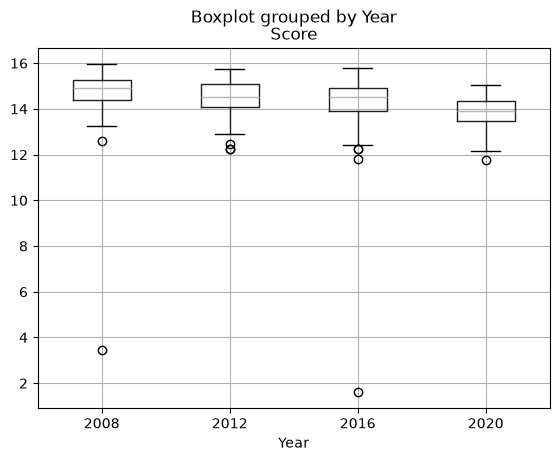

In [27]:
gym_long[gym_long["Event"] == "Floor Exercise"].boxplot(column="Score", by="Year")

12\. Standardize the scores for each of the six events by subtracting the mean for the event and dividing by its standard deviation *within each year*. Note: you can do this for all six events at once. You should NOT write a for loop or create a separate line of code for each event.


In [28]:
year_means = gym_scores.groupby(level="Year").transform("mean")
year_sds = gym_scores.groupby(level="Year").transform("std")
gym_year_z = (gym_scores - year_means) / year_sds
gym_year_z.head()

Floor Exercise  Horse Vault  \
Round         Year Gymnast                                          
Qualification 2012 Danell Leyva             0.753096     0.027915   
                   David Belyavsky          0.753096     1.451057   
                   Fabian HambÃ¼chen        0.794185     0.620298   
                   John Orozco              0.835273     0.561594   
                   Kristian Thomas          1.084294     1.273164   

                                      Parallel Bars  Horizontal Bar     Rings  \
Round         Year Gymnast                                                      
Qualification 2012 Danell Leyva            1.002995        1.708332  0.269011   
                   David Belyavsky         0.953577        0.569503 -0.128045   
                   Fabian HambÃ¼chen       0.953577        1.442985  0.550683   
                   John Orozco            -0.195024        1.025035  1.059729   
                   Kristian Thomas        -0.057251        1.138917  0.211319   

                                      Pommelled Horse  
Round         Year Gymnast                             
Qualification 2012 Danell Leyva              1.232874  
                   David Belyavsky           1.271729  
                   Fabian HambÃ¼chen         0.357497  
                   John Orozco               1.118595  
                   Kristian Thomas           0.395209

13\. If we standardize within each year, which athletes (and rounds and year) had the highest total standardized values? Basically repeat part 9 but with standardization within each year.

In [29]:
gym_year_z["total_z"] = gym_year_z.sum(axis=1, min_count=len(event_cols))
gym_year_z.sort_values("total_z", ascending=False).head(10)

Floor Exercise  Horse Vault  \
Round         Year Gymnast                                        
Final         2016 Oleh Verniaiev         0.520383     1.475149   
              2012 Kohei Uchimura         0.753096     1.390574   
Qualification 2020 Daiki Hashimoto        1.196662     1.341947   
Final         2020 Daiki Hashimoto        1.382156     1.070152   
Qualification 2016 Oleh Verniaiev         0.404528     0.837441   
Final         2016 Kohei Uchimura         0.944993     1.572128   
              2020 Nikita Nagorny         0.824279     1.397615   
Qualification 2020 Nikita Nagorny         1.707119     1.070152   
Final         2020 Xiao Ruoteng           1.196662     1.070152   
              2008 Yang Wei               0.403645     1.304573   

                                    Parallel Bars  Horizontal Bar     Rings  \
Round         Year Gymnast                                                    
Final         2016 Oleh Verniaiev        1.524323        0.534169  2.005141   
              2012 Kohei Uchimura        0.991015        1.405403  1.512779   
Qualification 2020 Daiki Hashimoto       1.007048        1.915265  0.443776   
Final         2020 Daiki Hashimoto       1.007048        1.802342  0.085413   
Qualification 2016 Oleh Verniaiev        1.600950        0.855432  1.822604   
Final         2016 Kohei Uchimura        0.943813        1.498922  0.970158   
              2020 Nikita Nagorny        1.102280        1.162069  1.304708   
Qualification 2020 Nikita Nagorny        0.688974        1.274992  0.946345   
Final         2020 Xiao Ruoteng          1.069901        0.823300  1.161578   
              2008 Yang Wei              1.246537        0.240300  2.291882   

                                    Pommelled Horse   total_z  
Round         Year Gymnast                                     
Final         2016 Oleh Verniaiev          1.554973  7.614139  
              2012 Kohei Uchimura          1.461432  7.514300  
Qualification 2020 Daiki Hashimoto         1.488590  7.393287  
Final         2020 Daiki Hashimoto         1.898201  7.245313  
Qualification 2016 Oleh Verniaiev          1.589606  7.110561  
Final         2016 Kohei Uchimura          0.890661  6.820674  
              2020 Nikita Nagorny          0.976575  6.767526  
Qualification 2020 Nikita Nagorny          1.078978  6.766560  
Final         2020 Xiao Ruoteng            1.421004  6.742597  
              2008 Yang Wei                1.234383  6.721320